In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 2. Load Dataset
df = pd.read_csv("StudentsPerformance.csv")

In [3]:
# 3. Compute Target Variable (Average Score)
df["Final_Score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

In [4]:
# 4. Select Features (example mapping)
df["study_hours"] = np.random.randint(1, 6, size=len(df))   # if not available
df["attendance"] = np.random.randint(70, 100, size=len(df))
df["sleep_hours"] = np.random.randint(5, 9, size=len(df))

In [5]:
# Encode categorical features
df["parental level of education"] = df["parental level of education"].astype("category").cat.codes
df["test preparation course"] = df["test preparation course"].astype("category").cat.codes

X = df[["study_hours", "attendance", 
        "parental level of education", 
        "test preparation course", 
        "sleep_hours"]]

y = df["Final_Score"]

In [ ]:
# 5. Handle Missing Values
X = X.fillna(X.mean())

In [7]:
# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [9]:
# 8. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# 9. Predictions
y_pred = model.predict(X_test)

In [11]:
# 10. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 208.54935730724884
RMSE: 14.441238080831187
R2 Score: 0.02713673801784322


In [22]:
# 11. Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)

                       Feature  Coefficient
0                  study_hours    -0.175970
1                   attendance     0.302443
2  parental level of education    -0.988493
3      test preparation course    -3.869441
4                  sleep_hours     0.347118


In [21]:
# 12. Ridge & Lasso
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Ridge R2:", ridge.score(X_test, y_test))
print("Lasso R2:", lasso.score(X_test, y_test))
print("Saravanan P 24BAD105")

Ridge R2: 0.027175798268591733
Lasso R2: 0.027456140891622405
Saravanan P 24BAD105


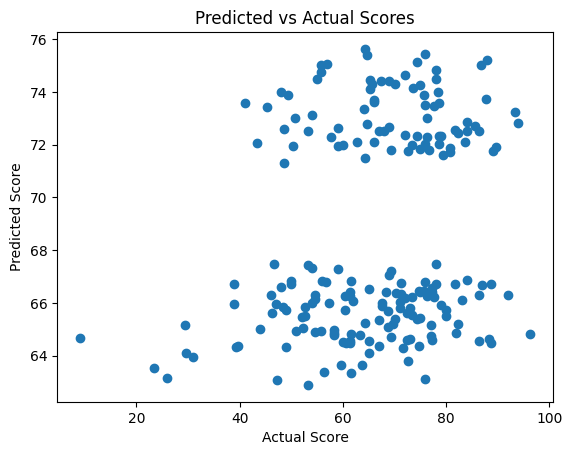

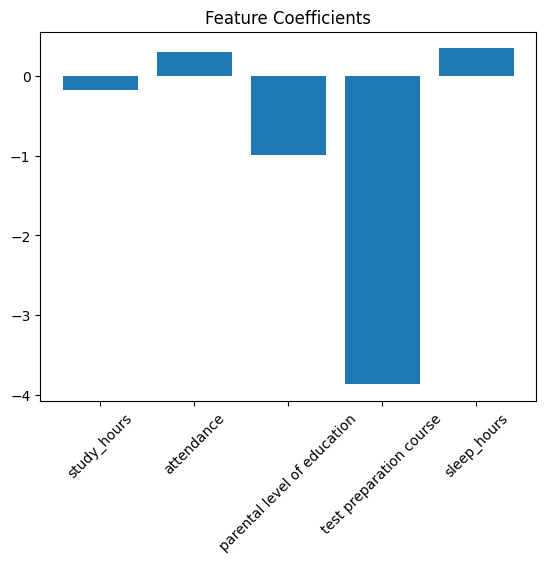

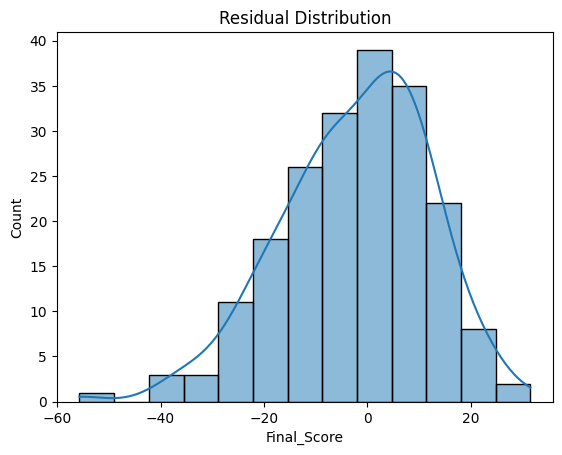

In [20]:
# 13. Visualization

# Predicted vs Actual
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Predicted vs Actual Scores")
plt.show()

# Coefficient Magnitude
plt.bar(X.columns, model.coef_)
plt.xticks(rotation=45)
plt.title("Feature Coefficients")
plt.show()

# Residual Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show() 